In [65]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages, AnyMessage

class AgentState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        messages: all messages
        question: question
        generation: LLM generation
        documents: list of documents
    """
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    # messages: Annotated[Sequence[BaseMessage], add_messages]
    messages: Annotated[list[AnyMessage], add_messages]
    question: str
    generation: str
    documents: List[str]

In [2]:
import getpass
import os


def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}:")


_set_env("OPENAI_API_KEY")

OPENAI_API_KEY: ········


In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import Docx2txtLoader, PyPDFLoader, TextLoader, CSVLoader, JSONLoader, DirectoryLoader

file_path = "./North_Korean_Tactics.pdf"
save_vector = "./north_korean_tactics_faiss_new"

def get_loader(filename):
    loader_classes = {
        'docx': Docx2txtLoader,
        'pdf': PyPDFLoader,
        'txt': TextLoader,
        'csv': CSVLoader,
        'json': JSONLoader,
        # 'hwp': HWPLoader
    }

    _, file_extension = os.path.splitext(filename)
    file_extension = file_extension.lstrip('.')

    loader_class = loader_classes.get(file_extension)

    if not loader_class:
        raise ValueError(f"No loader available for file extension '{file_extension}'")
    
    # JSON 파일인 경우 jq_schema 인자를 추가하여 반환
    if file_extension == 'json':
        return loader_class(filename, jq_schema='.', text_content=False)
    else:
        # 그 외의 경우 일반적인 방식으로 로더 반환
        return loader_class(filename)

loader = get_loader(file_path)

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=60, separators=["\n\n", "\n", ".", " ", ""]
)

doc_splits = text_splitter.split_documents(loader.load())

# Add to vectorDB
# vectorstore = Chroma.from_documents(
#     documents=doc_splits,
#     collection_name="rag-chroma",
#     embedding=OpenAIEmbeddings(),
# )

vectorstore = FAISS.from_documents(doc_splits, OpenAIEmbeddings())

vectorstore.save_local(save_vector)

retriever = vectorstore.as_retriever()

In [7]:
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_north_korean_tactics",
    "Search and return information about North Korean tactical doctrine manuals",
)

tools = [retriever_tool]

In [8]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class State1(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [9]:
from typing import Annotated, Literal, Sequence, TypedDict

# from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.utils.pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from langgraph.prebuilt import tools_condition

### Edges


def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"


### Nodes


def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )
    response = model.invoke(msg)
    return {"messages": [response]}


def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated state with re-phrased question
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    # prompt = hub.pull("rlm/rag-prompt")
    pull = """
        You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
    """
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", pull),
            ("human", "Question: {question}, Context: {context} "),
        ]
    )
    
    

    # LLM
    llm = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}


print("*" * 20 + "Prompt[rlm/rag-prompt]" + "*" * 20)

********************Prompt[rlm/rag-prompt]********************


In [10]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

# Define a new graph
workflow = StateGraph(State1)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
agentic_graph = workflow.compile()

In [11]:
### Retrieval Grader


# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
# docs = retriever.get_relevant_documents(question)
docs = retriever.invoke(question)
doc_txt = docs[1].page_content

In [12]:
### Generate

from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
# prompt = hub.pull("rlm/rag-prompt")

pull = """
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
"""
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", pull),
        ("human", "Question: {question}, Context: {context} "),
    ]
)


# LLM
llm = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})


In [13]:
### Hallucination Grader


# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(binary_score='yes')

In [14]:
### Answer Grader


# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='no')

In [15]:
### Question Re-writer

# LLM
llm = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

"What is the role of memory in an agent's functioning?"

In [16]:
from typing import List

from typing_extensions import TypedDict


class State2(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [19]:
from langchain_classic.schema import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [20]:
from langgraph.graph import END, StateGraph, START

workflow2 = StateGraph(State2)

# Define the nodes
workflow2.add_node("retrieve", retrieve)  # retrieve
workflow2.add_node("grade_documents", grade_documents)  # grade documents
workflow2.add_node("generate", generate)  # generate
workflow2.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow2.add_edge(
    START, "retrieve"
)

workflow2.add_edge("retrieve", "grade_documents")
workflow2.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow2.add_edge("transform_query", "retrieve")
workflow2.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
adaptive_graph = workflow2.compile()

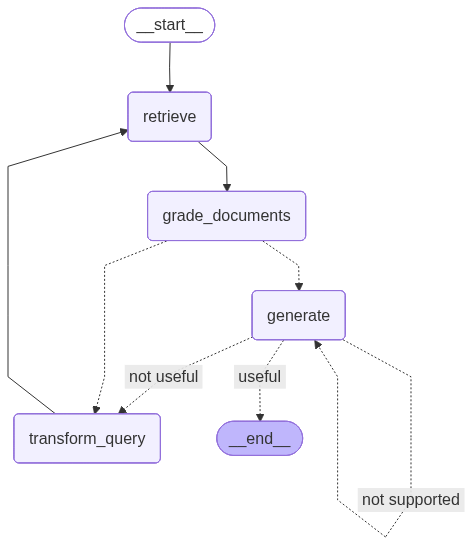

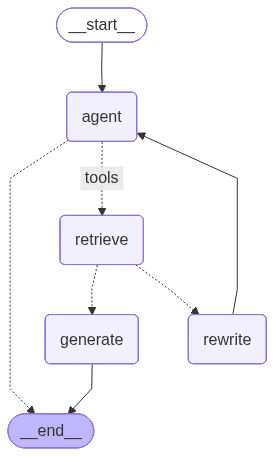

In [23]:
from IPython.display import Image, display

try:
    display(Image(adaptive_graph.get_graph(xray=True).draw_mermaid_png()))
    display(Image(agentic_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [81]:
from langchain_core.tools import tool
from langgraph.prebuilt import InjectedState

@tool
def run_agentic_rag(query: str) -> str:
    """RAG tool used for general questions about North Korean military tactics"""
    # 메인에서 받은 쿼리를 서브 그래프의 State 형식에 맞춰서 호출
    print("***********run_agentic_rag*****************")
    inputs = {"messages": [{"role": "user", "content": query}]}
    response = agentic_graph.invoke(inputs)
    # 서브 그래프의 최종 답변 텍스트만 쏙 빼서 리턴
    return response["messages"][-1].content

@tool
def run_adaptive_rag(query: str) -> str:
    """A RAG tool capable of returning verified results regarding North Korean tactics, including hallucinations and the suitability of the questions."""
    # 메인에서 받은 쿼리를 서브 그래프의 State 형식에 맞춰서 호출
    print("**************run_adaptive_rag****************")
    # inputs = {"messages": [{"role": "user", "content": query}]}
    sub_graph_input = {
        "question": f"{query}"
    }
    response = adaptive_graph.invoke(sub_graph_input)
    # 서브 그래프의 최종 답변 텍스트만 쏙 빼서 리턴
    return response["messages"][-1].content

In [82]:
rag_tools = [run_agentic_rag, run_adaptive_rag]

In [83]:
def main_agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """

    main_agent_prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                # "You are a military strategy expert with over 20 years of experience in the military domain."
                # "Use the provided tools to acquire information regarding North Korean tactics and answer the user's questions."
                "Select and use the tool 'run_agentic_rag' or 'run_adaptive_rag' among the following that best suits the user's question intent."
                "1. run_agentic_rag: General questions regarding North Korean tactics"
                "2. run_adaptive_rag: Questions regarding complex technical/informative North Korean tactics requiring sophisticated cross-verification and hallucination defense"
                " When searching, be persistent. Expand your query bounds if the first search returns no results."
                " If a search comes up empty, expand your search before giving up."
            ),
            ("placeholder", "{messages}"),
        ]
    )
    
    print("---CALL MAIN AGENT---")
    # messages = state["messages"]
    model = ChatOpenAI(
        api_key="ai",
        model="openai/gpt-oss-20b",
        base_url="http://192.168.0.110:8000/v1",
        temperature=0,
    )
    chain = main_agent_prompt | model.bind_tools(rag_tools)
    
    response = chain.invoke(state)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [84]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

workflow = StateGraph(AgentState)

workflow.add_node("agent", main_agent)
workflow.add_node("tools", ToolNode(rag_tools))

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    tools_condition
)

workflow.add_edge("tools", "agent")

main_graph = workflow.compile()

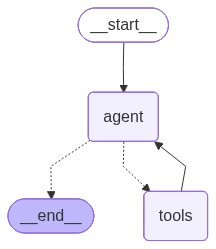

In [68]:
from IPython.display import Image, display

try:
    display(Image(main_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [85]:
import pprint

inputs = {
    # "messages": [
    #     ("user", "Please explain intelligence operations among North Korean tactics."),
    # ]
    "messages": [
        ("user", "Please explain North Korea's intelligence operations among its tactics based on facts and without delusion."),
    ]
}
for output in main_graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

---CALL MAIN AGENT---
"Output from node 'agent':"
'---'
{ 'messages': [ AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 297, 'total_tokens': 500, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'chatcmpl-8497a99bf05834df', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef3b1-2194-7ac2-8d21-9cd0330a9fb4-0', tool_calls=[{'name': 'run_adaptive_rag', 'args': {'query': 'North Korea intelligence operations tactics facts'}, 'id': 'chatcmpl-tool-b6d17c3d041d9bfb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 297, 'output_tokens': 203, 'total_tokens': 500, 'input_token_details': {}, 'output_token_details': {}})]}
'\n---\n'
**************run_adaptive_rag****************
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUME

KeyError: 'messages'